In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , OneHotEncoder ,LabelEncoder

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI python/projects/my tasks github/K-MEANS/Procurement KPI Analysis Dataset.csv')

In [ ]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [ ]:
df['Supplier'].unique()

array(['Alpha_Inc', 'Delta_Logistics', 'Gamma_Co', 'Beta_Supplies',
       'Epsilon_Group'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


We convert the time columns to a date format, create a time difference column, and convert it to the number of days.

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
df['lead_time_days'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

In [ ]:
df.describe()

,Order_Date,Delivery_Date,Quantity,Unit_Price,Negotiated_Price,Defective_Units,lead_time_days
count,777,690,777.000000,777.000000,777.000000,641.000000,690.000000
mean,2022-12-28 23:15:31.274131456,2023-01-12 03:16:10.434782720,1094.660232,58.283822,53.660721,74.803432,10.776812
min,2022-01-01 00:00:00,2022-01-06 00:00:00,51.000000,10.840000,9.270000,0.000000,-5.000000
25%,2022-07-02 00:00:00,2022-07-19 18:00:00,615.000000,33.290000,30.460000,26.000000,6.000000
50%,2022-12-24 00:00:00,2023-01-19 12:00:00,1075.000000,58.950000,53.800000,49.000000,11.000000
75%,2023-07-07 00:00:00,2023-07-18 00:00:00,1548.000000,83.130000,76.550000,100.000000,16.000000
max,2024-01-01 00:00:00,2024-01-12 00:00:00,5000.000000,109.170000,107.390000,321.000000,20.000000
std,NaN,NaN,647.844551,28.101315,26.094930,69.187870,5.729210


A negative number of days, such as -5, is impossible because the order date is after delivery. The entry might be incorrect, with the order date being substituted for the delivery date. It's also possible the order was rejected or is pending, in which case the delivery date would be zero.

In [ ]:
df.describe(include='object')

,PO_ID,Supplier,Item_Category,Order_Status,Compliance
count,777,777,777,777,777
unique,777,5,5,4,2
top,PO-00777,Delta_Logistics,Office Supplies,Delivered,Yes
freq,1,171,174,560,640


In [ ]:
df.isnull().sum()

,0
PO_ID,0
Supplier,0
Order_Date,0
Delivery_Date,87
Item_Category,0
Order_Status,0
Quantity,0
Unit_Price,0
Negotiated_Price,0
Defective_Units,136


Defective units are a result of inspection, and if they are not recorded in the delivered orders, this means there are no defects. However, in orders that have not yet been delivered or have been canceled, it is normal that there are currently no defects. Also, regarding the delivery date, the delivery date is 0 as long as delivery has not yet taken place.
However, the date cannot be compensated for because there are canceled or pending orders.

In [ ]:
df['Defective_Units'] = df['Defective_Units'].fillna(0)

In [ ]:
df.isnull().sum()

,0
PO_ID,0
Supplier,0
Order_Date,0
Delivery_Date,87
Item_Category,0
Order_Status,0
Quantity,0
Unit_Price,0
Negotiated_Price,0
Defective_Units,0


**DATA ENGINEERING**

In [ ]:
df['Order_Status'].unique()

array(['Cancelled', 'Delivered', 'Partially Delivered', 'Pending'],
      dtype=object)

In [ ]:
# إنشاء عمود يدل إذا كان الطلب مُسلّم فعلاً
df['is_delivered_any'] = df['Order_Status'].isin(['Delivered', 'Partially Delivered']).astype(int)

# حساب معدل التسليم لكل مورد
delivery_rate_per_supplier = df.groupby('Supplier')['is_delivered_any'].mean()


In [ ]:
# ضم المعدل إلى الداتا الأصلية في عمود جديد
df['delivery_rate'] = df['Supplier'].map(delivery_rate_per_supplier)


Defective Rate for each supplier

In [ ]:
# حساب معدل العيوب لكل مورد
supplier_defect_rate = (
    df.groupby('Supplier')
      .apply(lambda g: g['Defective_Units'].sum() / g['Quantity'].sum())
)

# إضافة العمود الجديد إلى الداتا الأصلية
df['defect_rate_per_supplier'] = df['Supplier'].map(supplier_defect_rate)


/tmp/ipykernel_10258/2338817661.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['Defective_Units'].sum() / g['Quantity'].sum())


In [ ]:
# معدّل العيوب على مستوى الطلب (مع تجنّب القسمة على صفر)
df['defect_rate_per_order'] = np.where(df['Quantity'] > 0, df['Defective_Units'] / df['Quantity'], 0.0)


In [ ]:

# حجم/ولوم التعامل
vol_aggs = df.groupby('Supplier').agg(
    n_orders       = ('PO_ID', 'count'),
    qty_total      = ('Quantity', 'sum'),
    ty_mean       = ('Quantity', 'mean'),

)
#نضيف الاعمدة باستخدام merg
df = df.merge(vol_aggs, on='Supplier', how='left')

In [ ]:

# السعر والخصم (متوسطات وانحراف معياري اختياري)
price_aggs = df.groupby('Supplier').agg(
    unit_price_mean = ('Unit_Price', 'mean'),
    neg_price_mean  = ('Negotiated_Price', 'mean')

)

df['unit_price_mean'] = df['Supplier'].map(price_aggs['unit_price_mean'])
df['neg_price_mean']  = df['Supplier'].map(price_aggs['neg_price_mean'])

# حساب معدل الخصم للمورد
price_aggs['discount_rate'] = price_aggs['neg_price_mean'] / price_aggs['unit_price_mean']
df['discount_rate']= df['Supplier'].map(price_aggs['discount_rate'])

In [ ]:

# الجودة
quality_aggs = df.groupby('Supplier').apply(
    lambda g: pd.Series({
        # عيوب لكل 1000 وحدة = 1000 * (sum(defective) / sum(qty))
        'defect_per_1k': 1000.0 * (g['Defective_Units'].sum() / g['Quantity'].sum() if g['Quantity'].sum() > 0 else 0.0),
        # متوسط معدّل العيوب عبر الطلبات
        'defect_rate_mean': g['defect_rate_per_order'].mean()
    })
)
df = df.merge(quality_aggs, on='Supplier', how='left')

/tmp/ipykernel_10258/1789454855.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quality_aggs = df.groupby('Supplier').apply(


In [ ]:
# الامتثال

df['compliance_is'] = (df['Compliance'].astype(str).str.strip().str.lower() == 'yes').astype(int)
compliance_aggs = df.groupby('Supplier')['compliance_is'].mean()

df['compliance_aggs']= df['Supplier'].map(compliance_aggs)

In [ ]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,...,n_orders,qty_total,ty_mean,unit_price_mean,neg_price_mean,discount_rate,defect_per_1k,defect_rate_mean,compliance_is,compliance_aggs
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,0.0,...,141,150414,1066.765957,58.386525,53.648156,0.918845,18.063478,0.018905,1,0.936170
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,...,171,181652,1062.292398,56.236023,51.898304,0.922866,108.328012,0.108666,1,0.608187
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,...,143,157916,1104.307692,59.348881,54.706713,0.921782,44.542668,0.044975,1,0.860140
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,...,156,180516,1157.153846,58.279423,53.607885,0.919842,76.658025,0.082723,1,0.756410
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,...,171,181652,1062.292398,56.236023,51.898304,0.922866,108.328012,0.108666,0,0.608187


In [ ]:
df.to_csv("ENGIN_DATA_SUPPLER.csv", index=False, encoding="utf-8-sig")

In [ ]:
model_features = ['Supplier','delivery_rate','defect_rate_per_supplier','defect_rate_mean','defect_per_1k','compliance_aggs','discount_rate','qty_total','n_orders']

In [ ]:
df_scaled = df[model_features].copy()

In [ ]:
ohe = OneHotEncoder(handle_unknown = "ignore")
supplier_array = ohe.fit_transform(df_scaled[['Supplier']]).toarray()

In [ ]:
supplier_ohe_df = pd.DataFrame(
    supplier_array,
    columns=ohe.get_feature_names_out(['Supplier'])
)


In [ ]:
df_scaled.drop('Supplier' , axis = 1 ,inplace=True)

In [ ]:
#supplier_level_df.drop('Supplier' , axis = 1 ,inplace=True)


In [ ]:
supplier_df = df_scaled.join(supplier_ohe_df)

In [ ]:
supplier_df


,delivery_rate,defect_rate_per_supplier,defect_rate_mean,defect_per_1k,compliance_aggs,discount_rate,qty_total,n_orders,Supplier_Alpha_Inc,Supplier_Beta_Supplies,Supplier_Delta_Logistics,Supplier_Epsilon_Group,Supplier_Gamma_Co
0,0.829787,0.018063,0.018905,18.063478,0.936170,0.918845,150414,141,1.0,0.0,0.0,0.0,0.0
1,0.807018,0.108328,0.108666,108.328012,0.608187,0.922866,181652,171,0.0,0.0,1.0,0.0,0.0
2,0.846154,0.044543,0.044975,44.542668,0.860140,0.921782,157916,143,0.0,0.0,0.0,0.0,1.0
3,0.788462,0.076658,0.082723,76.658025,0.756410,0.919842,180516,156,0.0,1.0,0.0,0.0,0.0
4,0.807018,0.108328,0.108666,108.328012,0.608187,0.922866,181652,171,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0.807018,0.108328,0.108666,108.328012,0.608187,0.922866,181652,171,0.0,0.0,1.0,0.0,0.0
773,0.829787,0.018063,0.018905,18.063478,0.936170,0.918845,150414,141,1.0,0.0,0.0,0.0,0.0
774,0.846154,0.044543,0.044975,44.542668,0.860140,0.921782,157916,143,0.0,0.0,0.0,0.0,1.0
775,0.788462,0.076658,0.082723,76.658025,0.756410,0.919842,180516,156,0.0,1.0,0.0,0.0,0.0


In [ ]:
scl = StandardScaler()
supplier_array =scl.fit_transform(supplier_df)

In [ ]:
supplier_scl_df = pd.DataFrame(supplier_array, columns=supplier_df.columns)

In [ ]:
supplier_scl_df.head()

,delivery_rate,defect_rate_per_supplier,defect_rate_mean,defect_per_1k,compliance_aggs,discount_rate,qty_total,n_orders,Supplier_Alpha_Inc,Supplier_Beta_Supplies,Supplier_Delta_Logistics,Supplier_Epsilon_Group,Supplier_Gamma_Co
0,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923
1,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923
2,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604
3,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923
4,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923


In [ ]:
supplier_scl_df

,delivery_rate,defect_rate_per_supplier,defect_rate_mean,defect_per_1k,compliance_aggs,discount_rate,qty_total,n_orders,Supplier_Alpha_Inc,Supplier_Beta_Supplies,Supplier_Delta_Logistics,Supplier_Epsilon_Group,Supplier_Gamma_Co
0,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923
1,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923
2,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604
3,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923
4,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923
...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923
773,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923
774,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604
775,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923


We note that the data was compiled according to the supplier through data engineering, and we still have 5 suppliers.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
inretia = []
for k in range(1,11):
  km = KMeans(n_clusters=k , random_state=42 ,n_init=20)
  km.fit(supplier_scl_df)
  inretia.append(km.inertia_)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

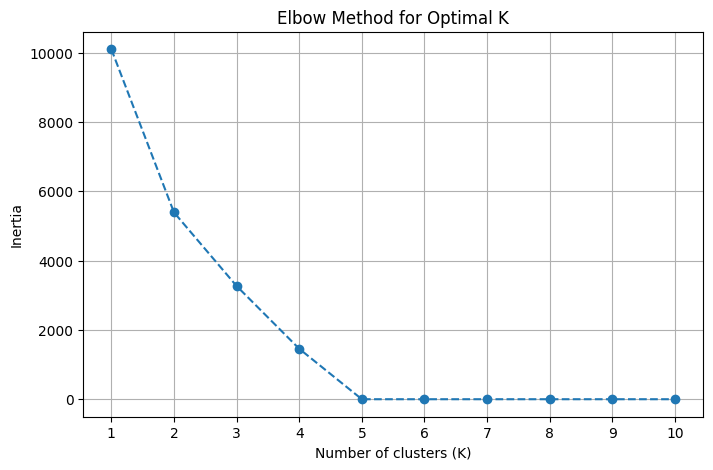

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inretia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

The best classification is at k = 5, as confirmed by the ElboW method.

**Now we build the final model**

In [ ]:

final_km_model = KMeans(n_clusters=5, random_state=42, n_init=20)
final_km_model.fit_predict(supplier_scl_df)

supplier_scl_df['Cluster'] = final_km_model.labels_
display(supplier_scl_df)

,delivery_rate,defect_rate_per_supplier,defect_rate_mean,defect_per_1k,compliance_aggs,discount_rate,qty_total,n_orders,Supplier_Alpha_Inc,Supplier_Beta_Supplies,Supplier_Delta_Logistics,Supplier_Epsilon_Group,Supplier_Gamma_Co,Cluster
0,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923,0
1,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923,1
2,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604,4
3,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923,3
4,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923,1
773,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923,0
774,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604,4
775,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923,3


In [ ]:
cluster_labels_unique = final_km_model.labels_
silhouette_avg= silhouette_score(supplier_scl_df,cluster_labels_unique)
print(f"The Silhouette Score for the K-Means clustering with K=5 is: {silhouette_avg:.4f}")

The Silhouette Score for the K-Means clustering with K=5 is: 1.0000


In [ ]:
supplier_scl_df.groupby('Cluster').mean()

,delivery_rate,defect_rate_per_supplier,defect_rate_mean,defect_per_1k,compliance_aggs,discount_rate,qty_total,n_orders,Supplier_Alpha_Inc,Supplier_Beta_Supplies,Supplier_Delta_Logistics,Supplier_Epsilon_Group,Supplier_Gamma_Co
Cluster,,,,,,,,,,,,,
0,0.768834,-1.118770,-1.116232,-1.118770,0.815669,-1.261066,-1.586698,-1.282677,2.123826,-0.501206,-0.531204,-0.521235,-0.474923
1,-0.389329,1.524900,1.459826,1.524900,-1.562560,1.477489,0.815740,1.228594,-0.470848,-0.501206,1.882514,-0.521235,-0.474923
2,-0.378577,-0.886224,-0.910825,-0.886224,1.147460,-0.540965,0.692765,0.810049,-0.470848,-0.501206,-0.531204,1.918521,-0.474923
3,-1.333166,0.597348,0.715294,0.597348,-0.487784,-0.581650,0.728373,-0.027041,-0.470848,1.995187,-0.531204,-0.521235,-0.474923
4,1.601310,-0.343247,-0.368044,-0.343247,0.264367,0.739141,-1.009737,-1.115259,-0.470848,-0.501206,-0.531204,-0.521235,2.105604


### 🟢 Cluster 0 — *High Quality & Reliable Suppliers*

**Characteristics:**

* Delivery rate: High (0.76) ✅
* Defect rate: Very low (-1.11) ✅
* Compliance: High (0.81) ✅
* Discount: Low ❗

**Interpretation:**
Suppliers in this cluster demonstrate excellent quality and strong compliance performance, but they offer limited discounts.

**Recommended Action:**

* Retain these suppliers
* Negotiate for better pricing

---

### 🔴 Cluster 1 — *High-Risk Suppliers*

**Characteristics:**

* Defect rate: Very high (1.52) ❌
* Compliance: Very poor (-1.56) ❌
* Discount: High (1.47)

**Interpretation:**
These suppliers compensate for poor quality and compliance by offering high discounts.

**Recommended Action:**

* Closely monitor performance
* Consider phasing them out or replacing them

---

### 🟡 Cluster 2 — *Stable High-Volume Suppliers*

**Characteristics:**

* Defect rate: Low ✅
* Compliance: High ✅
* Quantity & number of orders: High ✅

**Interpretation:**
Reliable suppliers with strong performance and high transaction volume.

**Recommended Action:**

* Prioritize and expand business with them

---

### 🟠 Cluster 3 — *Unstable Suppliers*

**Characteristics:**

* Delivery rate: Low ❌
* Defect rate: متوسط ❗
* Compliance: Low ❗

**Interpretation:**
Suppliers with inconsistent and unstable performance.

**Recommended Action:**

* Monitor closely and request improvements
* Limit dependency on them

---

### 🔵 Cluster 4 — *High-Potential Underutilized Suppliers*

**Characteristics:**

* Delivery rate: Very high (1.60) ✅
* Defect rate: Low ✅
* Number of orders: Low ❗

**Interpretation:**
High-performing suppliers that are currently underutilized.

**Recommended Action:**

* Increase engagement and expand collaboration
